In [20]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

conn = sqlite3.connect("../database/unipath.db")
df = pd.read_sql("SELECT * FROM students", conn)

print(f"Total rows: {len(df)}")
print(f"Columns: {df.columns.tolist()}")

Total rows: 157
Columns: ['id', 'source', 'pulled_at', 'school_raw', 'school_normalized', 'multi_school_flag', 'program_raw', 'program_category', 'decision', 'grade_11_avg', 'grade_12_avg', 'core_avg', 'ec_tags', 'circumstance_tags', 'province', 'citizenship', 'scholarship', 'comments_raw', 'ec_raw', 'circumstances_raw']


In [21]:
print(df["decision"].value_counts())

decision
ACCEPTED      141
DEFERRED       13
WAITLISTED      2
REJECTED        1
Name: count, dtype: int64


In [22]:
school_counts = df["school_normalized"].value_counts()
print(school_counts)

school_normalized
UBC Vancouver                        66
Simon Fraser University              23
UBC Okanagan                         13
University of Victoria               11
Western University                    8
University of Alberta                 6
McMaster University                   5
University of Toronto                 5
McGill University                     4
Queen's University                    2
University of Waterloo                2
Nipissing University                  1
University of Saskatchewan            1
Carleton University                   1
Wilfrid Laurier University            1
University of Toronto Mississauga     1
University of Ottawa                  1
University of Calgary                 1
Vancouver Island University           1
Bow Valley College                    1
BCIT                                  1
Name: count, dtype: int64


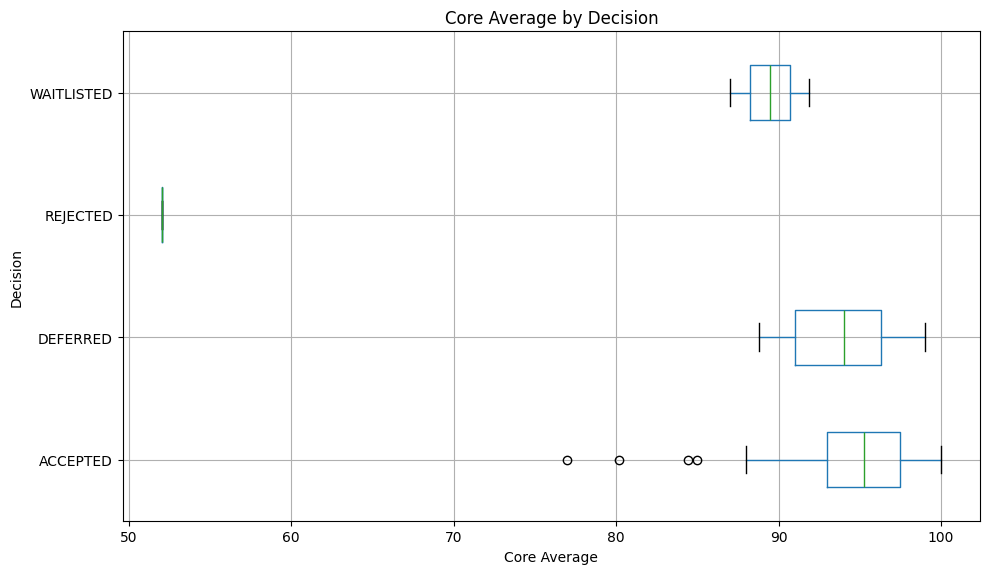

In [23]:
df.boxplot(column="core_avg", by="decision", figsize=(10, 6), vert=False)
plt.title("Core Average by Decision")
plt.suptitle("")
plt.xlabel("Core Average")
plt.ylabel("Decision")
plt.tight_layout()
plt.show()

In [24]:
school_stats = df.groupby("school_normalized").agg(
    total=("decision", "count"),
    accepted=("decision", lambda x: (x == "ACCEPTED").sum())
).reset_index()

school_stats["acceptance_rate"] = (school_stats["accepted"] / school_stats["total"] * 100).round(1)
school_stats = school_stats[school_stats["total"] >= 5].sort_values("acceptance_rate", ascending=False)
print(school_stats.to_string(index=False))

      school_normalized  total  accepted  acceptance_rate
    McMaster University      5         5            100.0
Simon Fraser University     23        23            100.0
  University of Alberta      6         6            100.0
  University of Toronto      5         5            100.0
 University of Victoria     11        11            100.0
     Western University      8         8            100.0
           UBC Okanagan     13        12             92.3
          UBC Vancouver     66        52             78.8


In [25]:
# What does the grade distribution look like for UBC Vancouver specifically?
ubc = df[df["school_normalized"] == "UBC Vancouver"]
print(f"UBC Vancouver: {len(ubc)} rows")
print(ubc["decision"].value_counts())
print()
print("Core avg by decision:")
print(ubc.groupby("decision")["core_avg"].describe().round(1))

UBC Vancouver: 66 rows
decision
ACCEPTED      52
DEFERRED      13
WAITLISTED     1
Name: count, dtype: int64

Core avg by decision:
            count  mean  std   min   25%   50%   75%    max
decision                                                   
ACCEPTED     49.0  96.2  2.3  91.5  95.0  97.0  98.0  100.0
DEFERRED     13.0  94.0  3.1  88.8  91.0  94.0  96.3   99.0
WAITLISTED    1.0  91.9  NaN  91.9  91.9  91.9  91.9   91.9
